In [2]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("Sample_ Superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.shape


(9994, 19)

In [10]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [12]:
df = df.dropna()

In [14]:
df["Sales"] = df["Sales"].fillna(df["Sales"].median())
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])

In [16]:
df.duplicated().sum()
df = df.drop_duplicates()

In [18]:
df.dtypes

Row ID            int64
Order ID         object
Order Date       object
Ship Date        object
Ship Mode        object
Customer ID      object
Segment          object
Country          object
City             object
State            object
Region           object
Product ID       object
Category         object
Sub-Category     object
Product Name     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [52]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

In [30]:
df[df["Sales"] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [32]:
df = df[df["Sales"] > 0]

In [54]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [56]:
df["Sales"] = df["Sales"].astype(float)

In [58]:
df.info()

df.describe()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Ship Date     9994 non-null   datetime64[ns]
 4   Ship Mode     9994 non-null   object        
 5   Customer ID   9994 non-null   object        
 6   Segment       9994 non-null   object        
 7   Country       9994 non-null   object        
 8   City          9994 non-null   object        
 9   State         9994 non-null   object        
 10  Region        9994 non-null   object        
 11  Product ID    9994 non-null   object        
 12  Category      9994 non-null   object        
 13  Sub-Category  9994 non-null   object        
 14  Product Name  9994 non-null   object        
 15  Sales         9994 non-null   float64 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,8,August,3
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,8,August,3
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,12,December,4
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,11,November,4
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,11,November,4


In [63]:
df.to_csv("cleaned_data.csv", index=False)

### EDA

In [66]:
print("Total Sales:", df["Sales"].sum())


Total Sales: 2297200.8603000003


In [68]:
print("Average Sale:", df["Sales"].mean())

Average Sale: 229.85800083049833


In [70]:
print("Average Sale:", df["Sales"].mean())

Average Sale: 229.85800083049833


In [72]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


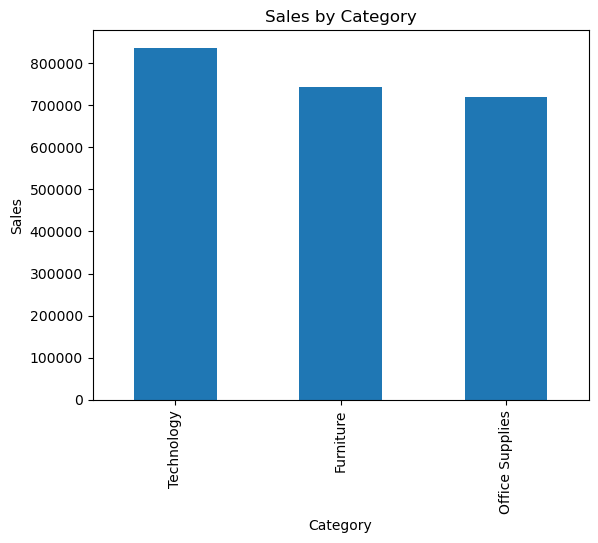

In [74]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

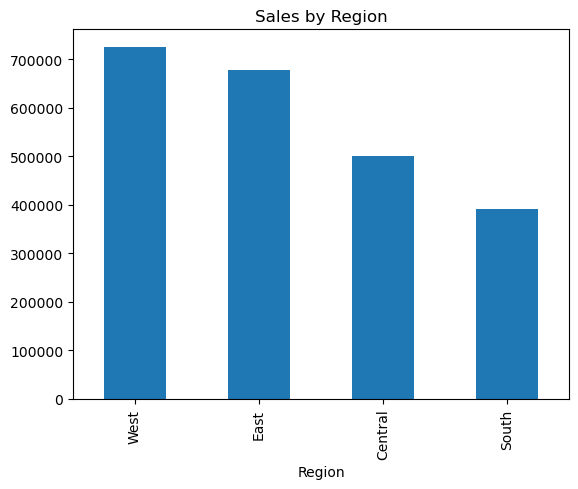

In [76]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

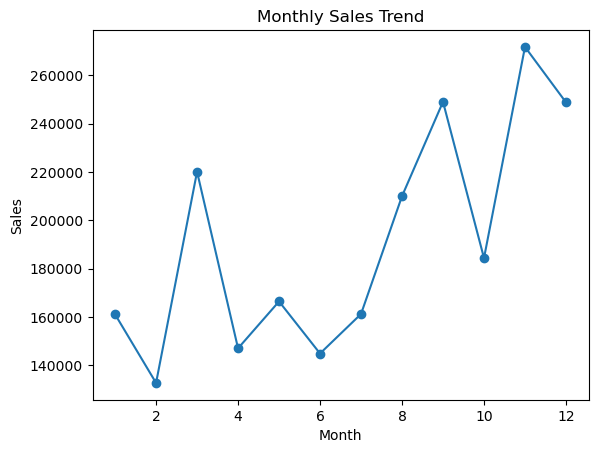

In [78]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

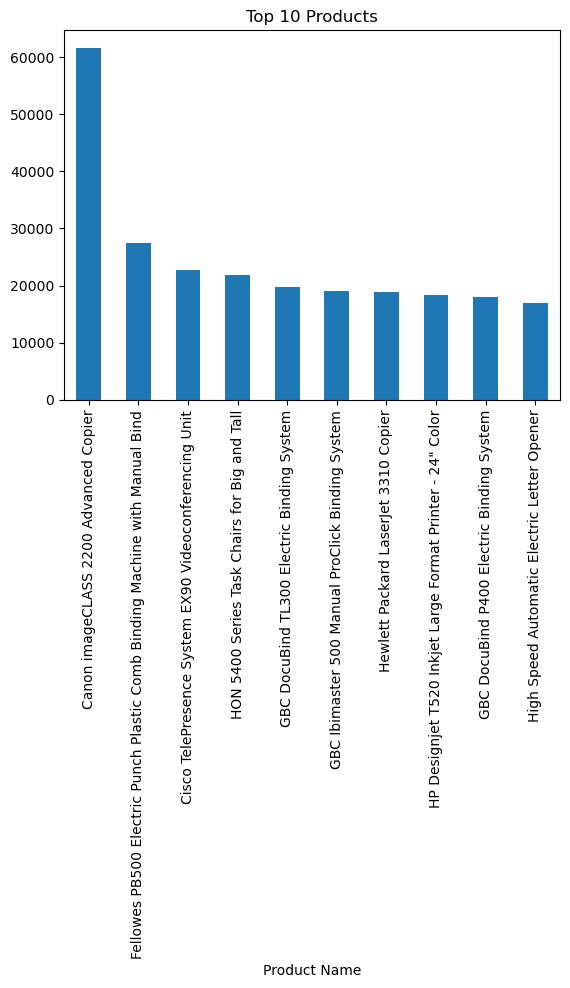

In [80]:
top_products = df.groupby("Product Name")["Sales"].sum().nlargest(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products")
plt.show()

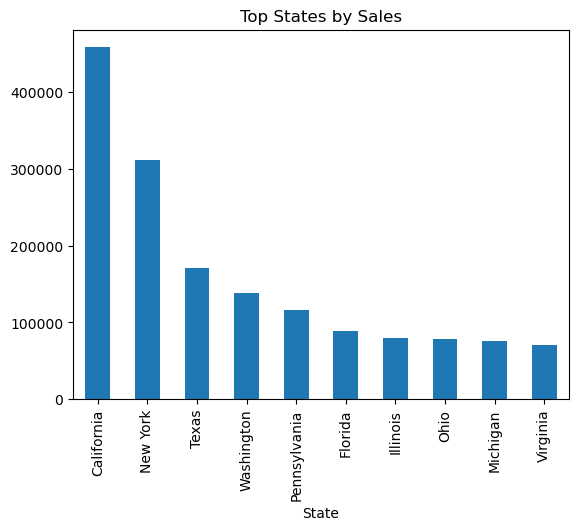

In [82]:
top_states = df.groupby("State")["Sales"].sum().nlargest(10)

top_states.plot(kind="bar")
plt.title("Top States by Sales")
plt.show()

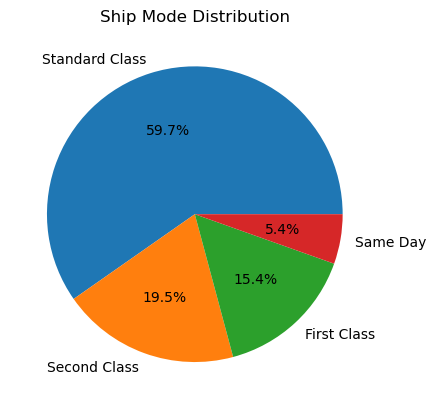

In [86]:
df["Ship Mode"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Ship Mode Distribution")
plt.ylabel("")
plt.show()

In [91]:
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

### ML

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [93]:
features = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode",
    "Year",
    "Month"
]

In [95]:
target = "Sales"

In [97]:
le = LabelEncoder()

for col in ["Category", "Sub-Category", "Region", "Segment", "Ship Mode"]:
    df[col] = le.fit_transform(df[col])

In [99]:
X = df[features]
y = df[target]

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [109]:
y_pred = model.predict(X_test)

In [111]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 255.46255912736274
RMSE: 762.3613746731943
R² Score: 0.016089911431658055


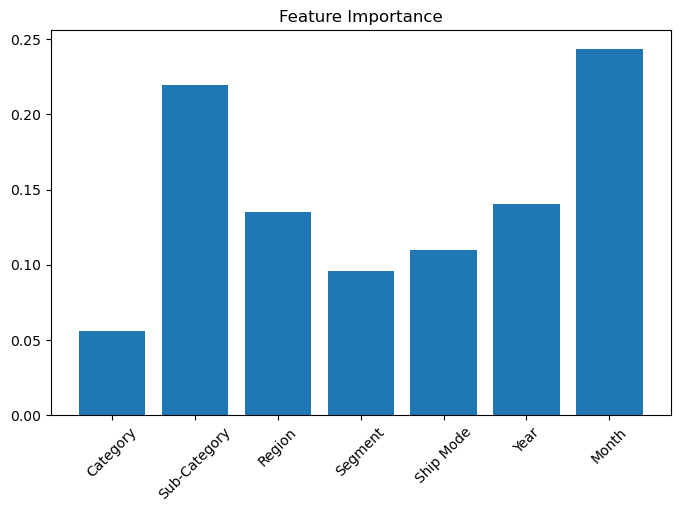

In [113]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [115]:
import joblib

joblib.dump(model, "sales_prediction_model.pkl")

['sales_prediction_model.pkl']